# Notebook 02 — Cell Structure and Function

**Module:** 05 — Biology Fundamentals  
**Notebook:** 02 of 18  
**Prerequisites:** NB01  
**Time estimate:** 60 minutes

---
## Step 1 — Motivation

All biological data ultimately comes from cells. RNA-seq measures gene expression
*in cells*. Single-cell experiments sequence individual *cells*. ChIP-seq measures
protein-DNA binding *in cells*. Understanding cell structure tells you where each
data type originates and what it measures.

---
## Step 2 — Intuition

Think of a eukaryotic cell as a factory:
- **Nucleus** = management office (stores the blueprints — DNA)
- **Ribosomes** = assembly lines (manufacture proteins from blueprints)
- **Mitochondria** = power plant (generate ATP from nutrients)
- **Endoplasmic reticulum** = shipping/folding department (processes proteins)
- **Golgi apparatus** = post office (sorts and dispatches proteins)
- **Plasma membrane** = factory walls + security gates (controls what enters/exits)
- **Cytoplasm** = factory floor (everything happens here)

---
## Step 3 — Biological Background

**Prokaryotes vs. Eukaryotes:**

| Feature | Prokaryote (e.g. *E. coli*) | Eukaryote (e.g. human cell) |
|---------|---------------------------|-----------------------------|
| Nucleus | Absent — DNA floats free | Present — DNA enclosed |
| Size | ~1–10 μm | ~10–100 μm |
| Organelles | None (some exceptions) | Mitochondria, ER, Golgi, etc. |
| Genome | Single circular chromosome | Multiple linear chromosomes |
| Gene structure | No introns | Introns present |
| RNA processing | Transcription + translation simultaneous | mRNA processed, exported, then translated |

**Why this matters for data:**
- Bacterial RNA-seq needs no splicing. Eukaryotic RNA-seq must handle introns.
- Human reference genome maps to nuclear DNA (+ mitochondrial DNA separately).
- Mitochondria have their own genome (16.6 kb in humans) — a common QC check.

**The cell cycle:**
G1 (growth) → S (DNA synthesis/replication) → G2 (preparation) → M (mitosis/division).
In single-cell RNA-seq, cell cycle state is a major confounding variable — cells in
S-phase express different genes than cells in G1.

---
## Step 4 — Mathematical Explanation

**Cell size and scale (orders of magnitude):**

| Object | Size |
|--------|------|
| Human cell | ~20 μm |
| Nucleus | ~5–10 μm |
| Mitochondrion | ~0.5–2 μm |
| Ribosome | ~25 nm |
| DNA double helix width | ~2 nm |
| Length of stretched human genome | ~2 meters |
| Packed into nucleus diameter | ~6 μm |

**The packaging problem:** 2 meters of DNA packed into a 6-μm nucleus requires
~10,000-fold compaction. The solution is chromatin: DNA wrapped around histone
protein spools. The compaction state (open = euchromatin, closed = heterochromatin)
directly controls gene accessibility — the basis of ATAC-seq and ChIP-seq.

---
## Step 6 — Python Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

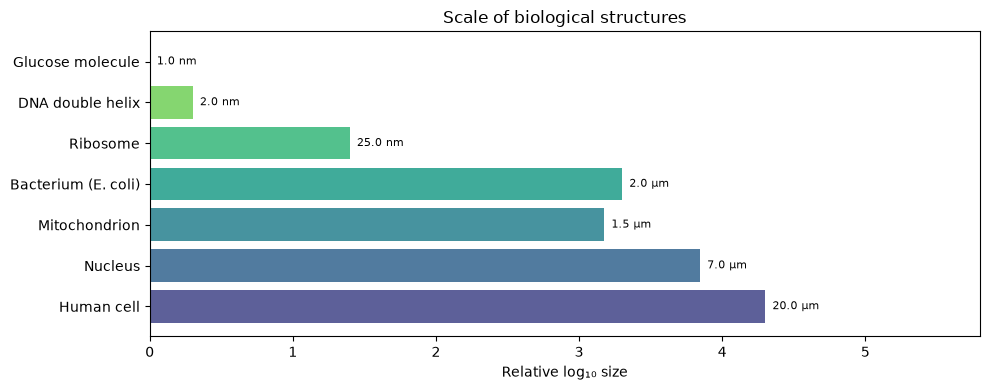

In [2]:
# Cell 6.1 — Scale comparison: biological objects
objects = {
    'Human cell': 20e-6,
    'Nucleus': 7e-6,
    'Mitochondrion': 1.5e-6,
    'Bacterium (E. coli)': 2e-6,
    'Ribosome': 25e-9,
    'DNA double helix': 2e-9,
    'Glucose molecule': 1e-9,
}

fig, ax = plt.subplots(figsize=(10, 4))
labels = list(objects.keys())
sizes_m = list(objects.values())
log_sizes = np.log10(sizes_m)

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(labels)))
bars = ax.barh(labels, log_sizes - log_sizes.min(), color=colors, alpha=0.85)
for bar, log_s, size in zip(bars, log_sizes, sizes_m):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{size*1e9:.1f} nm' if size < 1e-6 else f'{size*1e6:.1f} μm',
            va='center', fontsize=8)
ax.set_xlabel('Relative log₁₀ size')
ax.set_title('Scale of biological structures')
ax.set_xlim(0, max(log_sizes - log_sizes.min()) + 1.5)
plt.tight_layout()
plt.show()

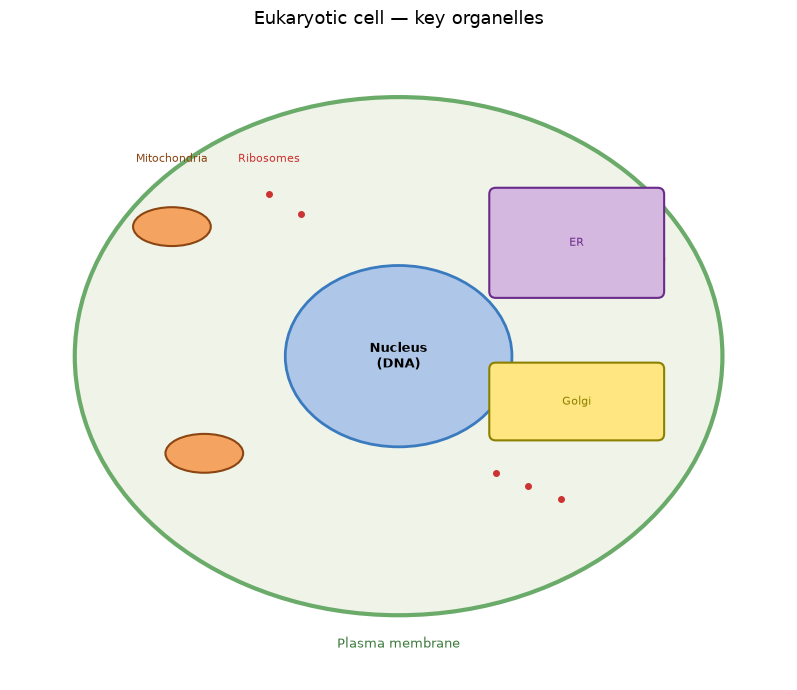

In [3]:
# Cell 6.2 — Simplified eukaryotic cell diagram
fig, ax = plt.subplots(figsize=(9, 7))
ax.set_xlim(-1, 11); ax.set_ylim(-1, 9); ax.set_aspect('equal'); ax.axis('off')
ax.set_title('Eukaryotic cell — key organelles', fontsize=13)

# Plasma membrane
cell = patches.Ellipse((5, 4), 10, 8, fill=True, facecolor='#f0f4e8', edgecolor='#6aab6a', lw=3)
ax.add_patch(cell)

# Nucleus
nucleus = patches.Ellipse((5, 4), 3.5, 2.8, fill=True, facecolor='#aec6e8', edgecolor='#3a7abf', lw=2)
ax.add_patch(nucleus)
ax.text(5, 4, 'Nucleus\n(DNA)', ha='center', va='center', fontsize=9, fontweight='bold')

# Mitochondria
for (x, y) in [(1.5, 6), (8.5, 5.5), (2, 2.5)]:
    mito = patches.Ellipse((x, y), 1.2, 0.6, fill=True, facecolor='#f4a460', edgecolor='#8b4513', lw=1.5)
    ax.add_patch(mito)
ax.text(1.5, 7, 'Mitochondria', ha='center', fontsize=8, color='#8b4513')

# Ribosomes (dots)
for (x, y) in [(3,6.5),(3.5,6.2),(7,2),(7.5,1.8),(6.5,2.2)]:
    ax.plot(x, y, 'o', ms=4, color='#cc3333')
ax.text(3, 7, 'Ribosomes', ha='center', fontsize=8, color='#cc3333')

# ER and Golgi
er = patches.FancyBboxPatch((6.5, 5), 2.5, 1.5, boxstyle='round,pad=0.1',
                            facecolor='#d4b8e0', edgecolor='#6a2b8a', lw=1.5)
ax.add_patch(er)
ax.text(7.75, 5.75, 'ER', ha='center', va='center', fontsize=8, color='#6a2b8a')

golgi = patches.FancyBboxPatch((6.5, 2.8), 2.5, 1.0, boxstyle='round,pad=0.1',
                               facecolor='#ffe680', edgecolor='#8b8000', lw=1.5)
ax.add_patch(golgi)
ax.text(7.75, 3.3, 'Golgi', ha='center', va='center', fontsize=8, color='#8b8000')

ax.text(5, -0.5, 'Plasma membrane', ha='center', fontsize=9, color='#3a7a3a')
plt.tight_layout()
plt.show()

In [4]:
# Cell 6.3 — DNA compaction calculation
genome_bp    = 3.2e9          # human haploid genome: 3.2 billion base pairs
bp_per_meter = 3e8            # ~0.34 nm per bp → 1 m = ~3e9 bp; diploid × 2
dna_length_m = genome_bp * 0.34e-9 * 2   # diploid: both copies
nucleus_diam_m = 6e-6

compaction = dna_length_m / nucleus_diam_m

print(f"Human diploid genome length (stretched): {dna_length_m:.2f} m")
print(f"Nucleus diameter:                        {nucleus_diam_m*1e6:.1f} μm")
print(f"Required compaction factor:              ~{compaction:,.0f}×")
print()
print("This is why chromatin accessibility (ATAC-seq, ChIP-seq)")
print("fundamentally controls which genes can be transcribed.")

Human diploid genome length (stretched): 2.18 m
Nucleus diameter:                        6.0 μm
Required compaction factor:              ~362,667×

This is why chromatin accessibility (ATAC-seq, ChIP-seq)
fundamentally controls which genes can be transcribed.


---
## Step 8 — Exercises

1. List the six main organelles described in this notebook. For each, write one
   sentence explaining its function **in terms of what a bioinformatics analysis
   might measure about it** (not just its general function).
2. Why does single-cell RNA-seq need to correct for cell cycle phase? Which genes
   would you expect to be highly expressed in S-phase?
3. Mitochondria have their own genome. What are the implications for read mapping
   in a whole-genome sequencing experiment? (Hint: how many copies of mtDNA
   exist per cell compared to nuclear DNA?)
4. Calculate: if each base pair is 0.34 nm and the human genome is 3.2 × 10⁹ bp,
   how long is one copy of the DNA if stretched out? How does this compare to
   a typical human height?

---
## Quiz — Active Recall

1. What is the key structural difference between prokaryotic and eukaryotic cells?
2. What is the function of the nucleus? Of ribosomes? Of mitochondria?
3. What is chromatin? Why does its compaction state matter for gene expression?
4. What are the four phases of the cell cycle? Which phase replicates DNA?
5. Why does RNA-seq from bacteria not need to handle splicing, but RNA-seq from
   human cells does?

---
## Reflection

**Date completed:** ____________________

> *[Draw a cell from memory and label 5 organelles with their functions. Compare to the diagram above.*
> *What would you look up?]*

---
*Next: `03_central_dogma_dna_rna_protein.ipynb`*